# YOUTUBE RECOMMENDATION DATASET


With the rapid growth of online video platforms, YouTube has become one of the most influential content-sharing and recommendation-driven systems in the world. Millions of videos are uploaded daily, making it essential to understand user engagement patterns and content characteristics that influence video popularity and recommendations.

This project focuses on performing Exploratory Data Analysis (EDA) on a YouTube Recommendation Dataset to gain insights into video performance and user interaction behavior. The dataset contains information related to video metadata such as view count, like count, comment count, engagement rate, video duration, category, and publication time.

The objective of this analysis is to explore the underlying structure of the dataset, identify meaningful patterns, detect anomalies, and understand the relationships between different features. Additionally, feature engineering techniques are applied to create new variables that help better represent engagement, popularity, and temporal aspects of videos.

By visualizing distributions, correlations, and trends, this EDA helps in understanding how different factors contribute to video recommendations and audience engagement. The insights obtained from this analysis can be useful for content creators, data analysts, and recommendation system designers to optimize content strategy and improve recommendation performance.

##### Import Required Libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore') 

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

##### Load Dataset 

In [74]:
df=pd.read_csv(r"C:\Users\ACER\Downloads\youtube_recommendation_dataset -.csv")


##### Data Types and Info

In [75]:
print('Data Types:')
print(df.dtypes)
print('\nDataset Info:')
print(df.info())

Data Types:
Title                       object
channel_title               object
published_at                object
category_id                  int64
view_count                   int64
like_count                   int64
comment_count                int64
favorite_count               int64
duration                    object
definition                  object
caption                       bool
engagement_rate            float64
likes_to_views_ratio       float64
comments_to_views_ratio    float64
duration_seconds             int64
video_age_days               int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537 entries, 0 to 536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Title                    537 non-null    object 
 1   channel_title            537 non-null    object 
 2   published_at             537 non-null    object 
 3   category_id        

##### Checking Missing Values

In [76]:
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
Title                      0
channel_title              0
published_at               0
category_id                0
view_count                 0
like_count                 0
comment_count              0
favorite_count             0
duration                   0
definition                 0
caption                    0
engagement_rate            0
likes_to_views_ratio       0
comments_to_views_ratio    0
duration_seconds           0
video_age_days             0
dtype: int64


##### Convert date column

In [77]:
df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce')
df = df.dropna(subset=['published_at'])
df['published_at'].dtype

datetime64[ns, UTC]

##### Name of Columns

In [78]:
df.columns

Index(['Title', 'channel_title', 'published_at', 'category_id', 'view_count',
       'like_count', 'comment_count', 'favorite_count', 'duration',
       'definition', 'caption', 'engagement_rate', 'likes_to_views_ratio',
       'comments_to_views_ratio', 'duration_seconds', 'video_age_days'],
      dtype='object')

##### First five rows

In [79]:
df.head(3)


,Title,channel_title,published_at,category_id,view_count,like_count,comment_count,favorite_count,duration,definition,caption,engagement_rate,likes_to_views_ratio,comments_to_views_ratio,duration_seconds,video_age_days
0,LA PERVERSA X LA INSUPERABLE X ALOFOKE MUSIC X...,AlofokeMusicSounds,2025-11-16 15:34:55+00:00,10,1405647,140463,9063,0,PT1M51S,hd,False,0.106375,0.099928,0.006448,111,1
1,Moana | Official Teaser,Disney,2025-11-17 17:00:47+00:00,24,2776847,26801,6684,0,PT1M,hd,True,0.012059,0.009652,0.002407,60,0
2,$0 - $1 Trillion Only FISHING in Steal a Brain...,CaylusBlox,2025-11-17 22:57:14+00:00,20,1189857,16174,1827,0,PT18M2S,hd,False,0.015129,0.013593,0.001535,1082,0


##### Last five rows

In [80]:
df.tail(3)

,Title,channel_title,published_at,category_id,view_count,like_count,comment_count,favorite_count,duration,definition,caption,engagement_rate,likes_to_views_ratio,comments_to_views_ratio,duration_seconds,video_age_days
534,Arc Raiders - Before You Buy,gameranx,2025-10-31 21:57:47+00:00,20,1218921,28356,3146,0,PT14M14S,hd,True,0.025844,0.023263,0.002581,854,17
535,Clair Obscur: Expedition 33 Review,IGN,2025-04-23 09:00:23+00:00,20,1220485,16187,2947,0,PT17M48S,hd,False,0.015677,0.013263,0.002415,1068,209
536,Must Play Mobile Game-Epic War!😎 #shorts #game...,MohanadPC,2025-08-24 16:00:39+00:00,20,2157893,7439,12,0,PT32S,hd,False,0.003453,0.003447,0.000006,32,85


##### Checking for Duplicates

In [81]:
print('Number of Duplicate Rows:', df.duplicated().sum())

Number of Duplicate Rows: 0


##### Statistical Summary

In [82]:
df.describe()

,category_id,view_count,like_count,comment_count,favorite_count,engagement_rate,likes_to_views_ratio,comments_to_views_ratio,duration_seconds,video_age_days
count,537.000000,5.370000e+02,5.370000e+02,537.000000,537.0,537.000000,537.000000,537.000000,537.000000,537.000000
mean,22.456238,2.145752e+07,4.336044e+05,7125.700186,0.0,0.028722,0.027692,0.001030,4802.746741,934.050279
std,5.854776,4.015200e+07,8.386711e+05,36075.115032,0.0,0.020608,0.019708,0.002166,13748.249437,904.546132
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.676921e+06,5.559100e+04,1018.000000,0.0,0.015579,0.015301,0.000115,52.000000,261.000000
50%,24.000000,6.385911e+06,1.550550e+05,2354.000000,0.0,0.024368,0.023565,0.000398,390.000000,658.000000
75%,27.000000,2.270604e+07,4.631890e+05,5925.000000,0.0,0.037366,0.036282,0.000954,1639.000000,1363.000000
max,28.000000,3.697310e+08,1.087934e+07,810641.000000,0.0,0.215744,0.199095,0.026031,105227.000000,4772.000000


##### Skewness Analysis

In [83]:
numeric_cols = ['view_count', 'like_count', 'comment_count',
                'engagement_rate', 'likes_to_views_ratio',
                'comments_to_views_ratio', 'duration_seconds']

df[numeric_cols].skew()

view_count                  4.424063
like_count                  5.838464
comment_count              20.785119
engagement_rate             2.396508
likes_to_views_ratio        2.232448
comments_to_views_ratio     5.868449
duration_seconds            4.349417
dtype: float64

##### Univariate Analysis

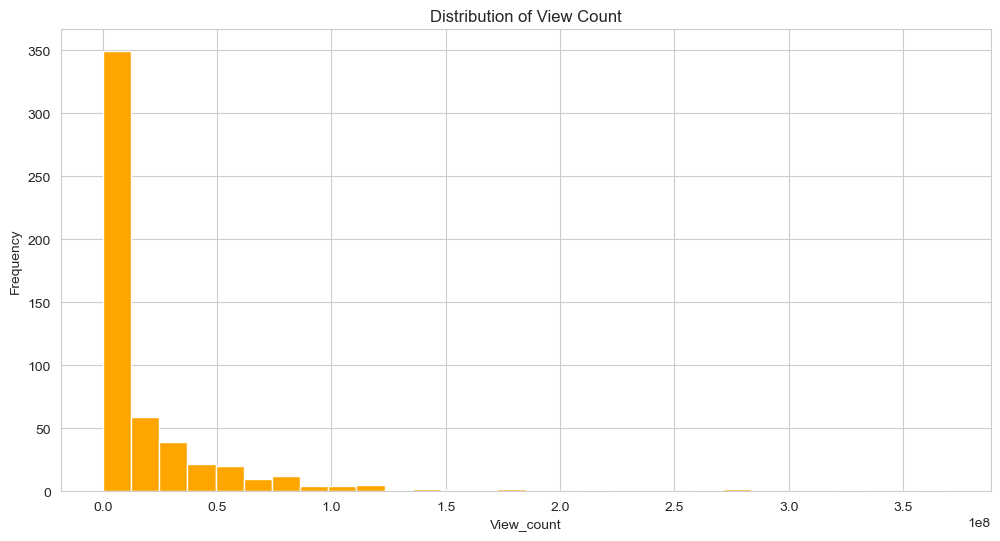

In [84]:
plt.hist(df['view_count'],bins=30,color='orange')
plt.title('Distribution of View Count')
plt.xlabel('View_count')
plt.ylabel('Frequency')
plt.show()

##### Category-wise Analysis 

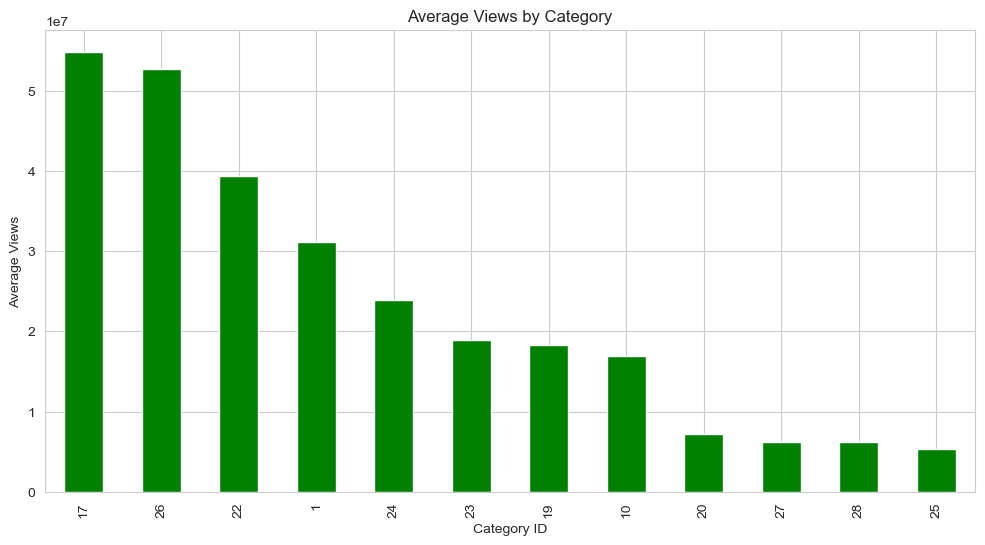

In [85]:
category_views = df.groupby('category_id')['view_count'].mean().sort_values(ascending=False)
plt.figure()
category_views.plot(kind='bar',color='green')
plt.title('Average Views by Category')
plt.xlabel('Category ID')
plt.ylabel('Average Views')
plt.show()


##### Video Definition

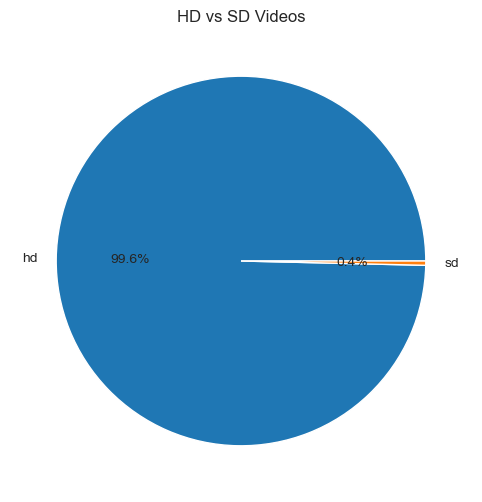

In [86]:
plt.figure()
df['definition'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('HD vs SD Videos')
plt.ylabel('')
plt.show()

##### Correlation Analysis 

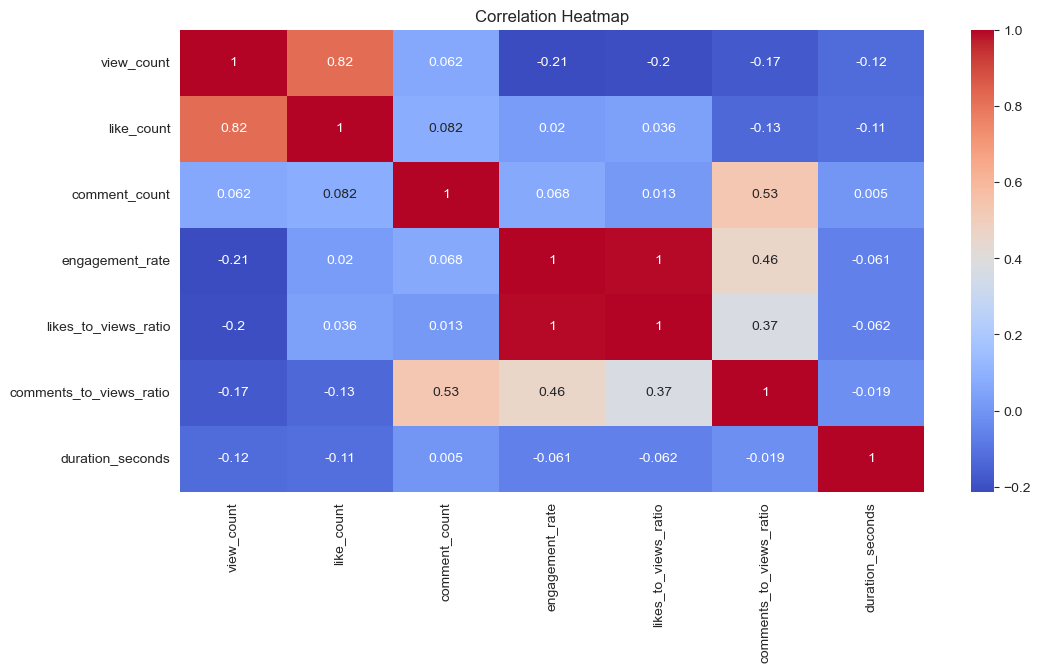

In [87]:
correlation = df[numeric_cols].corr()
plt.figure()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


##### Top Channels Analysis

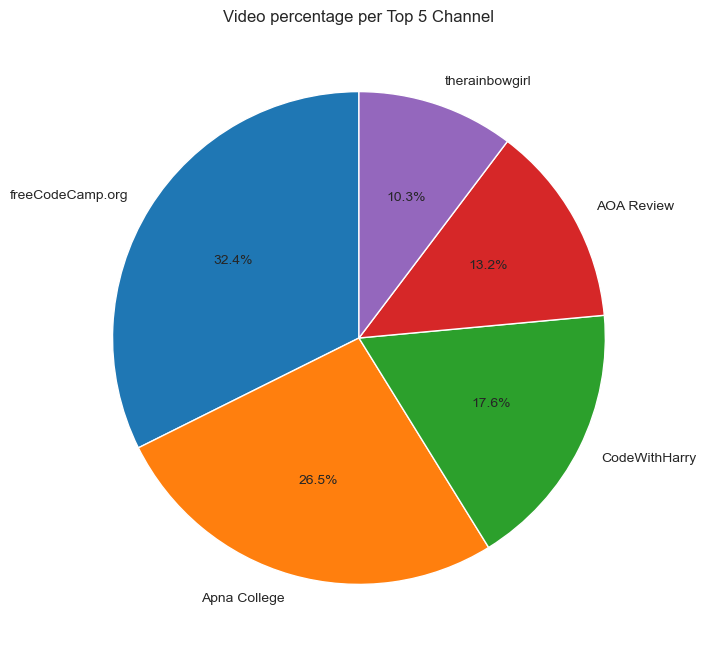

In [88]:
top_channels = df['channel_title'].value_counts().head(5)
plt.figure(figsize=(8,8))
top_channels.plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.title('Video percentage per Top 5 Channel')
plt.ylabel('')
plt.show()



## Feature Engineering

#### Engagement Level

In [89]:
threshold = df['engagement_rate'].median()
df['engagement_level'] = np.where(df['engagement_rate'] >= threshold, 'High', 'Low')
print(df.head(10).to_string())

                                                                  Title       channel_title              published_at  category_id  view_count  like_count  comment_count  favorite_count    duration definition  caption  engagement_rate  likes_to_views_ratio  comments_to_views_ratio  duration_seconds  video_age_days engagement_level
0  LA PERVERSA X LA INSUPERABLE X ALOFOKE MUSIC X SHADOW BLOW - BANDIDA  AlofokeMusicSounds 2025-11-16 15:34:55+00:00           10     1405647      140463           9063               0     PT1M51S         hd    False         0.106375              0.099928                 0.006448               111               1             High
1                                               Moana | Official Teaser              Disney 2025-11-17 17:00:47+00:00           24     2776847       26801           6684               0        PT1M         hd     True         0.012059              0.009652                 0.002407                60               0              Low
2

##### VIDEO LENGTH CATEGORY

In [90]:
df['video_length_category'] = pd.cut(
    df['duration_seconds'],
    bins=[0, 300, 900, 1800, df['duration_seconds'].max()],
    labels=['Short', 'Medium', 'Long', 'Very Long'])
print(df[['duration_seconds', 'video_length_category']].to_string())

     duration_seconds video_length_category
0                 111                 Short
1                  60                 Short
2                1082                  Long
3                 203                 Short
4                 215                 Short
5                4431             Very Long
6                 193                 Short
7                 123                 Short
8                1033                  Long
9                 176                 Short
10                 33                 Short
11               1046                  Long
12                222                 Short
13                 94                 Short
14               2155             Very Long
15                207                 Short
16                 60                 Short
17                612                Medium
18                175                 Short
19                 70                 Short
20               3872             Very Long
21                208           

##### Views Trend Over Time

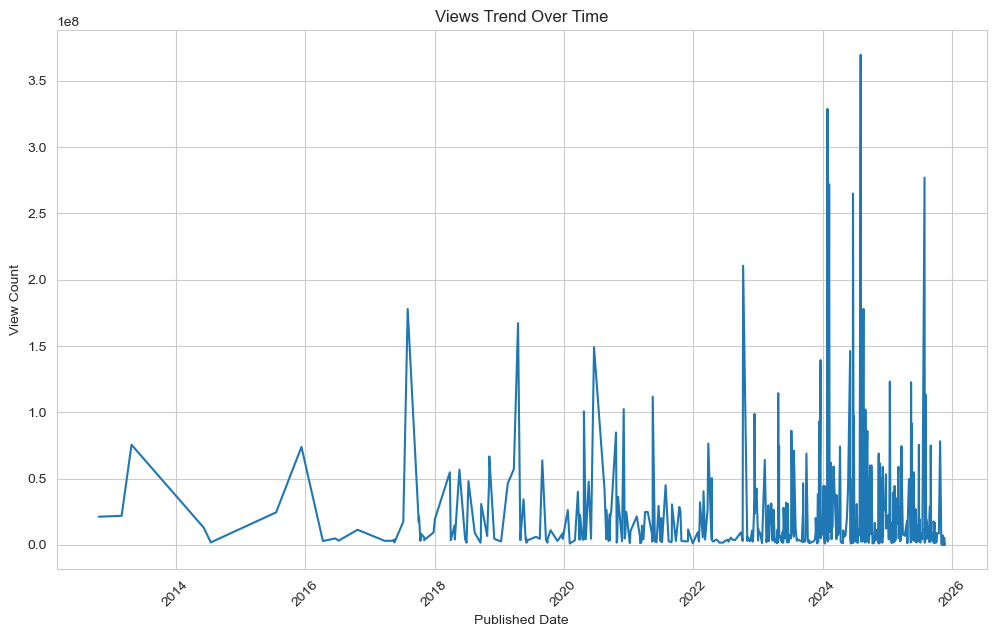

In [91]:
df_sorted = df.sort_values('published_at')

plt.figure(figsize=(12,7))
plt.plot(df_sorted['published_at'], df_sorted['view_count'])
plt.title('Views Trend Over Time')
plt.xlabel('Published Date')
plt.ylabel('View Count')
plt.xticks(rotation=45)
plt.show()


##### INTERACTION RATIO

In [92]:
df['like_to_comment_ratio'] = df['like_count'] / (df['comment_count'] + 1)
print(df.head(10).to_string())

                                                                  Title       channel_title              published_at  category_id  view_count  like_count  comment_count  favorite_count    duration definition  caption  engagement_rate  likes_to_views_ratio  comments_to_views_ratio  duration_seconds  video_age_days engagement_level video_length_category  like_to_comment_ratio
0  LA PERVERSA X LA INSUPERABLE X ALOFOKE MUSIC X SHADOW BLOW - BANDIDA  AlofokeMusicSounds 2025-11-16 15:34:55+00:00           10     1405647      140463           9063               0     PT1M51S         hd    False         0.106375              0.099928                 0.006448               111               1             High                 Short              15.496801
1                                               Moana | Official Teaser              Disney 2025-11-17 17:00:47+00:00           24     2776847       26801           6684               0        PT1M         hd     True         0.012059          

##### ENGAGEMENT RATE DISTRIBUTION

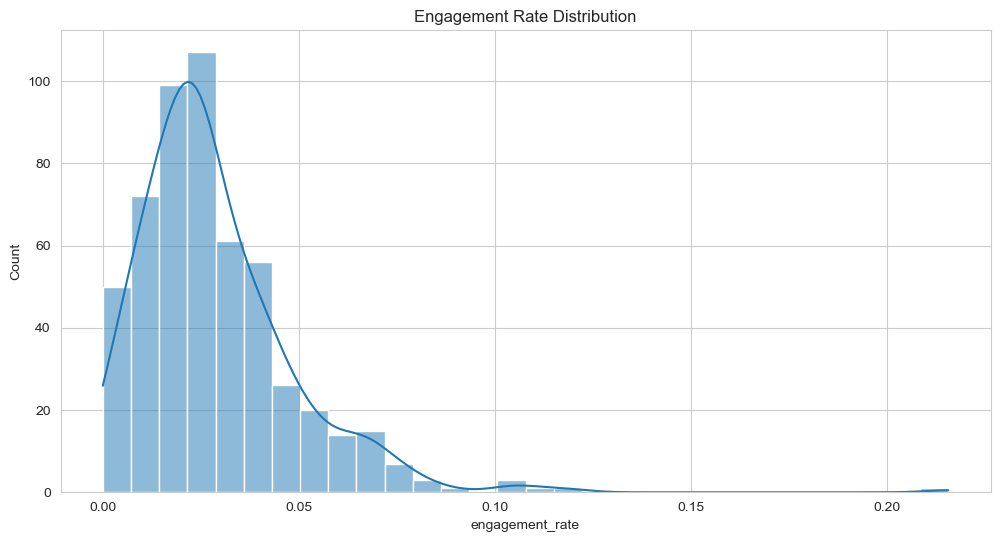

In [93]:
plt.figure()
sns.histplot(df['engagement_rate'], bins=30, kde=True)
plt.title("Engagement Rate Distribution")
plt.show()


##### VIEWS VS LIKES

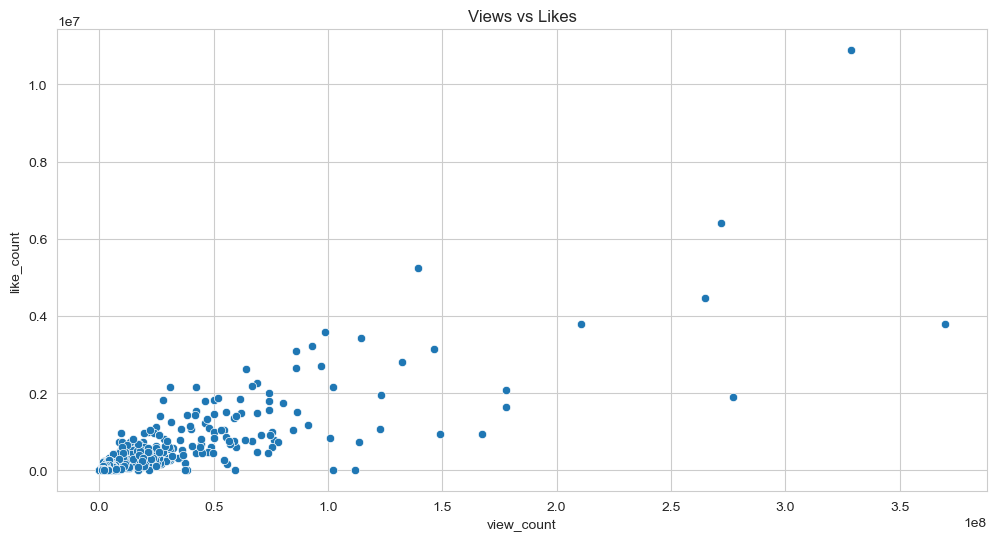

In [94]:
plt.figure()
sns.scatterplot(x='view_count', y='like_count', data=df)
plt.title("Views vs Likes")
plt.show()


##### VIDEO LENGTH VS ENGAGEMENT

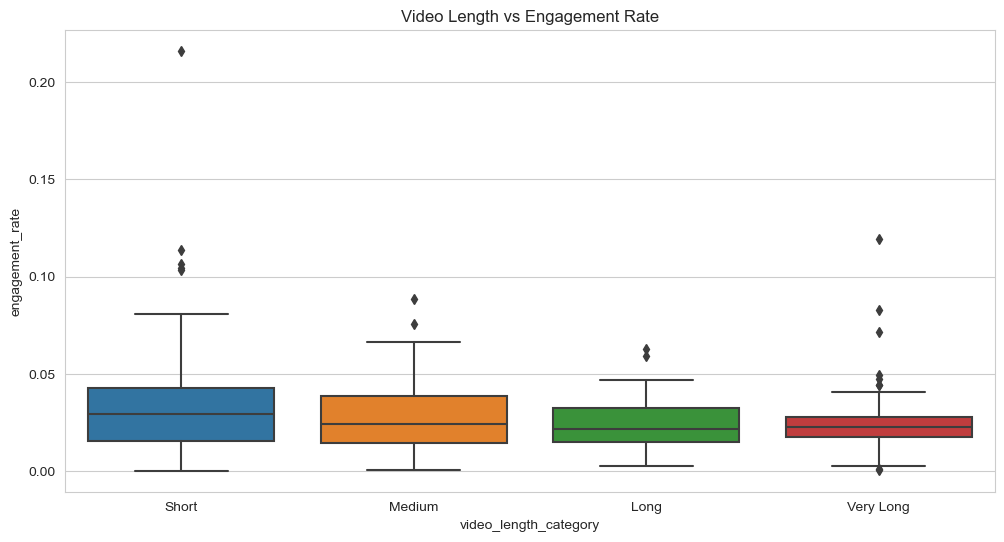

In [95]:
plt.figure()
sns.boxplot(x='video_length_category', y='engagement_rate', data=df)
plt.title("Video Length vs Engagement Rate")
plt.show()


#### High Views and High Like Count

In [96]:
high_views_likes = df[
    (df['view_count'] > df['view_count'].median()) &
    (df['like_count'] > df['like_count'].median())
]

high_views_likes[['Title', 'view_count', 'like_count']].head()


,Title,view_count,like_count
50,Python Full Course for Beginners,46262391,1222760
51,Python for Beginners - Learn Coding with Pytho...,23108733,530447
52,But what is a neural network? | Deep learning ...,21325565,511165
53,AI Learns to Walk (deep reinforcement learning),12181385,233272
54,AI Learns to Dodge #ai #deeplearning #aiwareh...,11628193,524073


#### Old Videos or Very High Views

In [97]:
old_or_viral = df[
    (df['video_age_days'] > df['video_age_days'].median()) |
    (df['view_count'] > df['view_count'].quantile(0.75))
]

old_or_viral[['Title', 'video_age_days', 'view_count']].head()


,Title,video_age_days,view_count
50,Python Full Course for Beginners,2464,46262391
51,Python for Beginners - Learn Coding with Pytho...,1888,23108733
52,But what is a neural network? | Deep learning ...,2965,21325565
53,AI Learns to Walk (deep reinforcement learning),939,12181385
55,Deep Learning Cars,3312,11360687


#### Engagement Rate by Caption

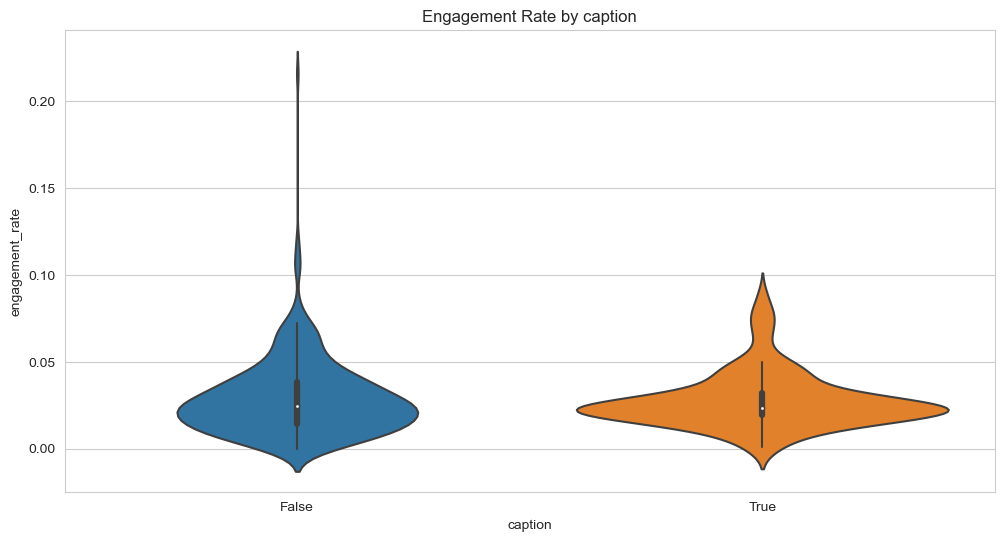

In [98]:
plt.figure()
sns.violinplot(x='caption', y='engagement_rate', data=df)
plt.title('Engagement Rate by caption')
plt.show()

#### QUESTIONS TO WORK WITH THIS DATASET 

#####  1.What is the overall distribution of video view counts, and are there any extreme outliers?

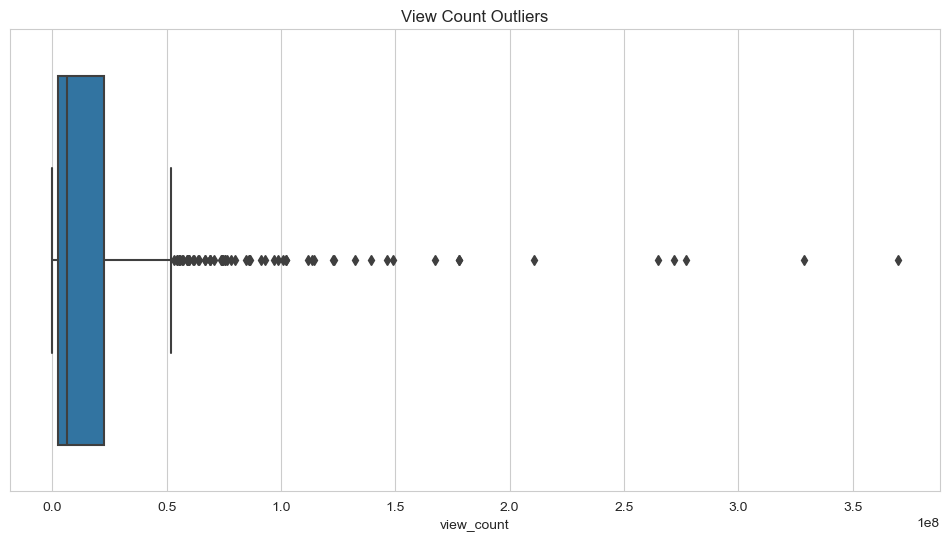

count    5.370000e+02
mean     2.145752e+07
std      4.015200e+07
min      0.000000e+00
25%      2.676921e+06
50%      6.385911e+06
75%      2.270604e+07
max      3.697310e+08
Name: view_count, dtype: float64

In [99]:
plt.figure()
sns.boxplot(x=df['view_count'])
plt.title("View Count Outliers")
plt.show()

df['view_count'].describe()


##### 2.How do likes and comments vary with respect to the number of views?

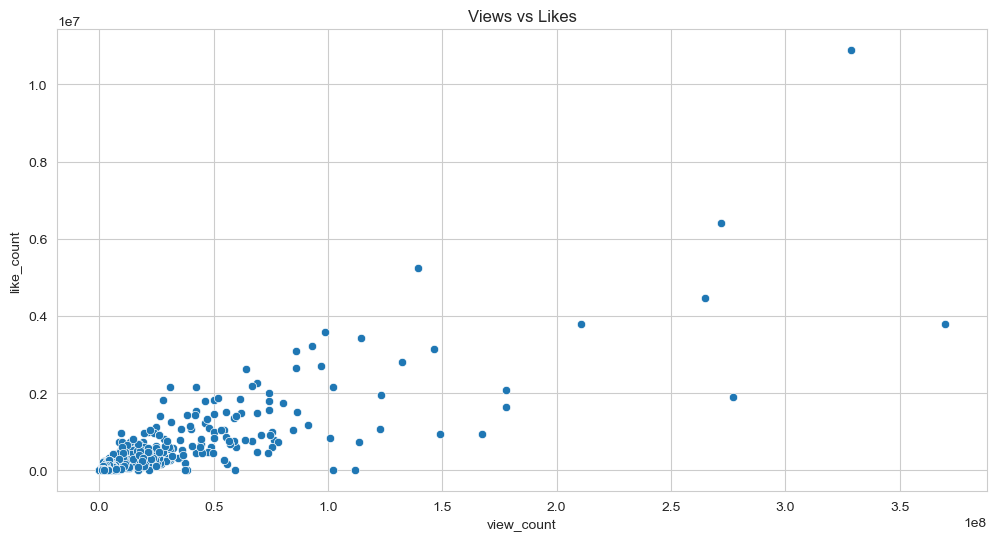

In [100]:
plt.figure()
sns.scatterplot(x='view_count', y='like_count', data=df)
plt.title("Views vs Likes")
plt.show()


 ##### 3.How does video definition (HD/SD) affect engagement?

<Figure size 1200x600 with 0 Axes>

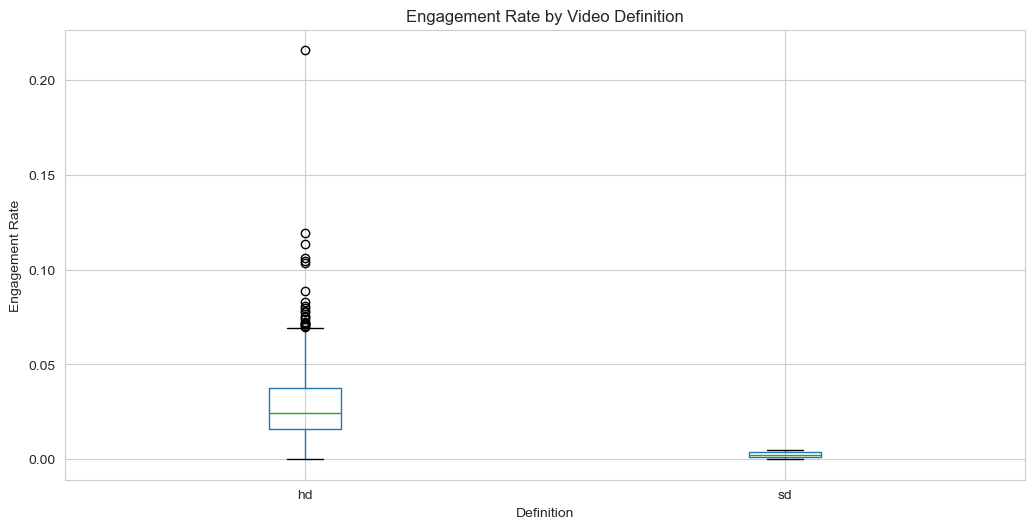

In [ ]:
plt.figure()
df.boxplot(column='engagement_rate', by='definition')
plt.title('Engagement Rate by Video Definition')
plt.suptitle('')
plt.xlabel('Definition')
plt.ylabel('Engagement Rate')
plt.show()


##### 4.Is there a significant relationship between video duration and user engagement rate?

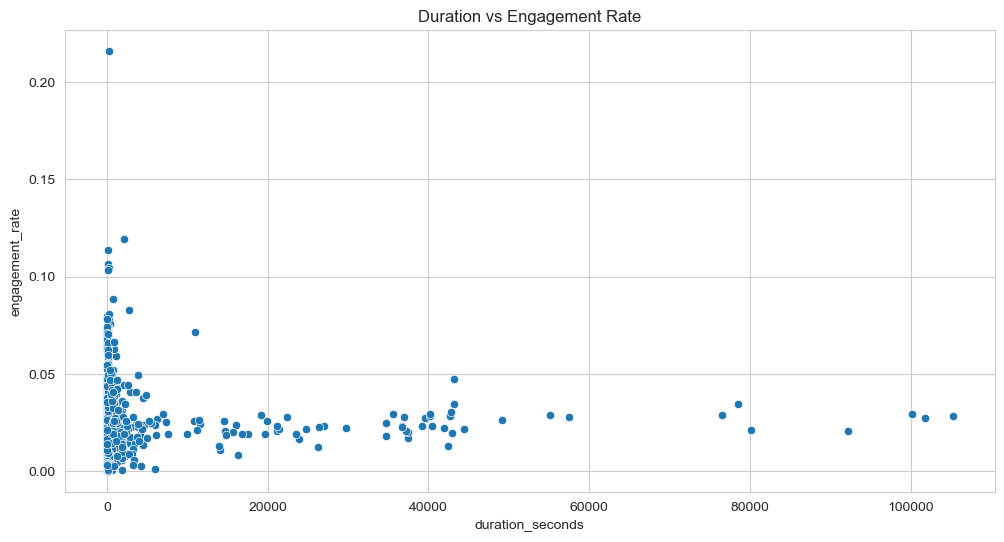

In [ ]:
plt.figure()
sns.scatterplot(x='duration_seconds', y='engagement_rate', data=df)
plt.title("Duration vs Engagement Rate")
plt.show()


 #### 5.Which category has the highest average engagement rate?

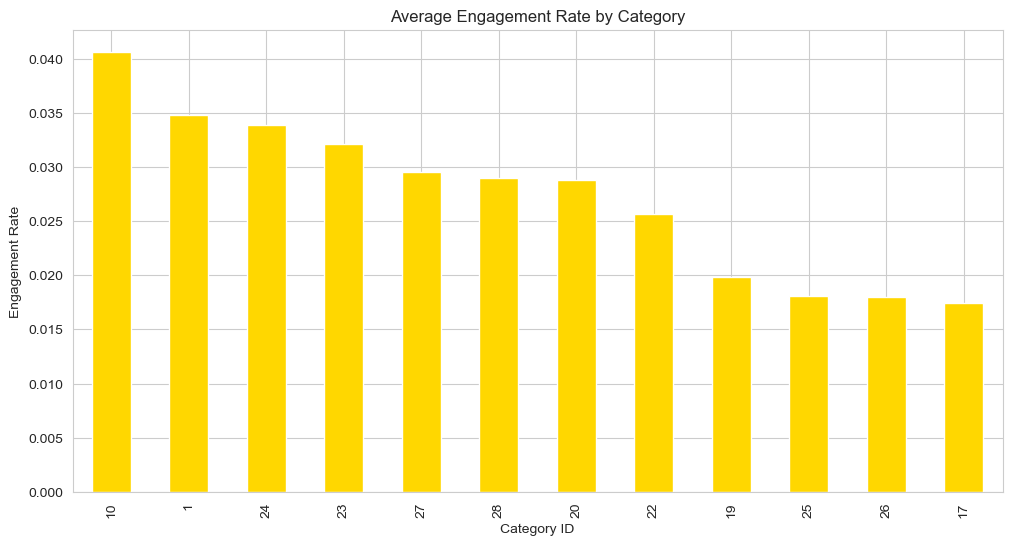

In [ ]:
category_engagement = df.groupby('category_id')['engagement_rate'].mean().sort_values(ascending=False)
plt.figure()
category_engagement.plot(kind='bar',color='gold')
plt.title('Average Engagement Rate by Category')
plt.xlabel('Category ID')
plt.ylabel('Engagement Rate')
plt.show()


##### 6.Which features show the strongest correlation with video popularity?

In [ ]:
corr = df[['view_count','like_count','comment_count',
           'engagement_rate','duration_seconds',
           'video_age_days']].corr()

corr['view_count'].sort_values(ascending=False)


view_count          1.000000
like_count          0.818828
comment_count       0.062265
video_age_days      0.023476
duration_seconds   -0.124261
engagement_rate    -0.212569
Name: view_count, dtype: float64

##### 7.How does engagement rate vary across different video length categories?

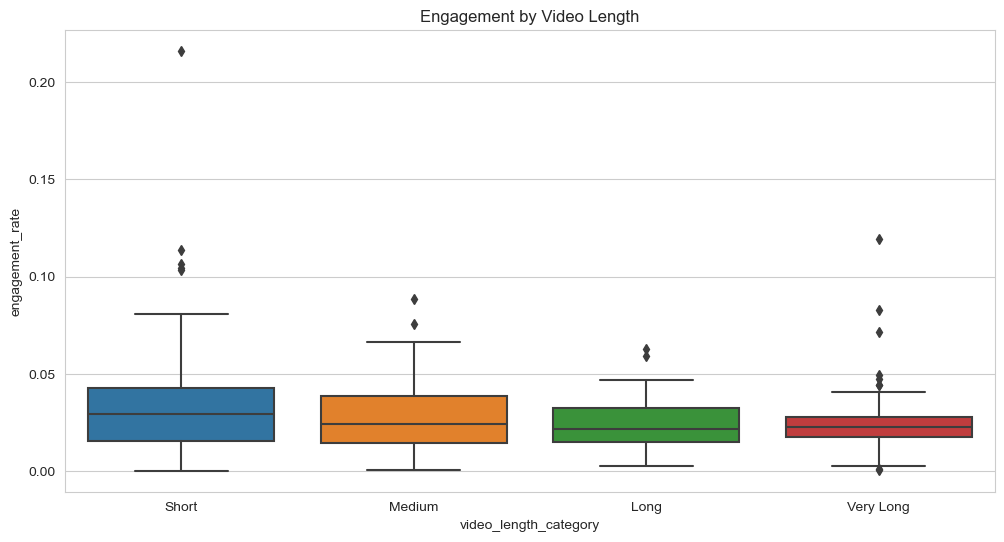

In [ ]:
plt.figure()
sns.boxplot(x='video_length_category', y='engagement_rate', data=df)
plt.title("Engagement by Video Length")
plt.show()


### CONCLUSION

The EDA on the YouTube Recommendation Dataset showed that a few videos dominate views, likes, and comments, while most receive moderate engagement. Engagement rate revealed the quality of interaction beyond popularity. Video duration, category, upload timing, and video age significantly affect performance. Feature engineering highlighted patterns in user engagement and content strategy. These insights can help creators optimize uploads and improve recommendation outcomes.